In [ ]:
# ============================================================
# Wine Classification using K-Nearest Neighbors (KNN)
# ------------------------------------------------------------
# Name      : Haris Farooq
# Reg No    : 2024395
# Course No : AI221L
# Task No   : 2
# ------------------------------------------------------------

In [12]:
import pandas as pd           #all the  required  utilities
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from sklearn.datasets import load_wine    #using scikit learns wine dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

In [ ]:
print("Shape of features:", X.shape)      #dataset features
print("Shape of target:", y.shape)
print("\nFirst 5 rows of features:\n", X.head())
print("\nTarget distribution:\n", y.value_counts())

Shape of features: (178, 13)
Shape of target: (178,)

First 5 rows of features:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82         

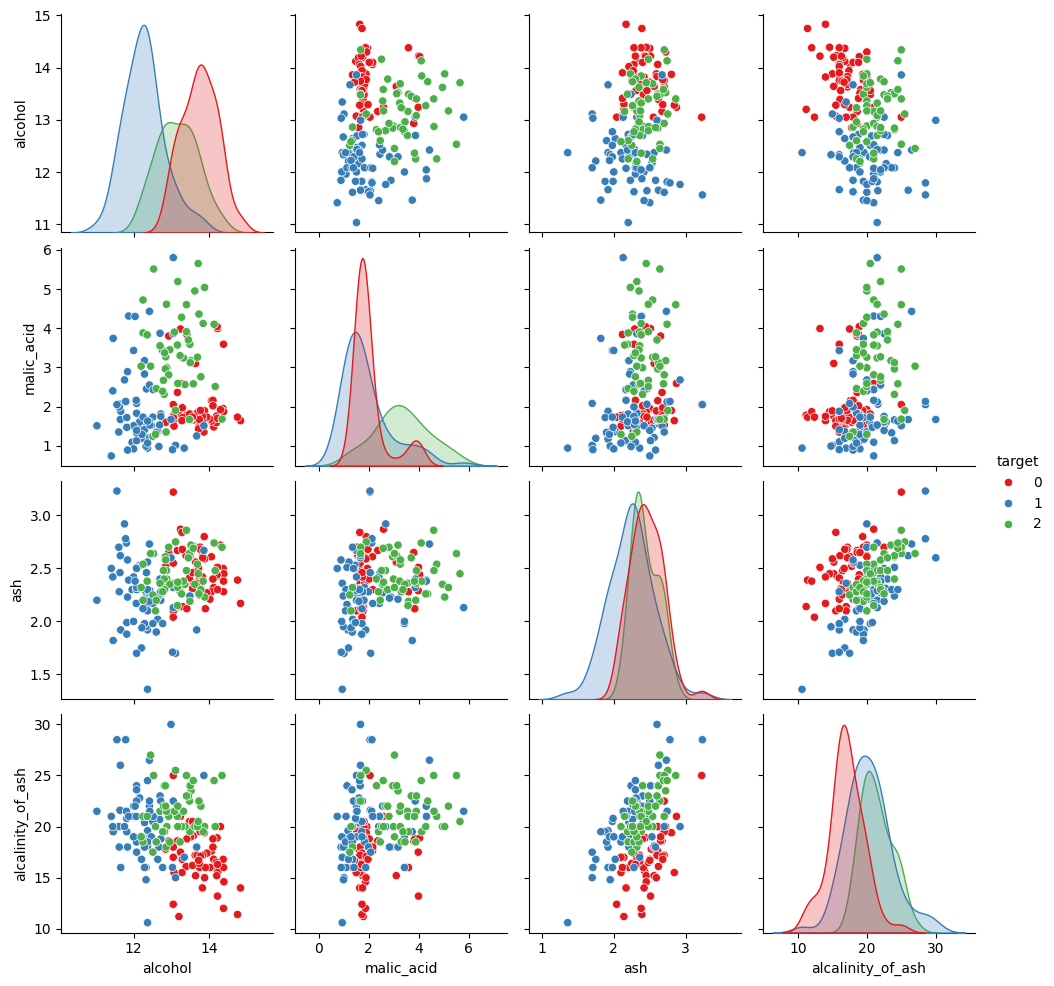

In [ ]:
sns.pairplot(pd.concat([X.iloc[:, :4], y], axis=1), hue='target', palette='Set1')
plt.show()  # Pairplot for first 4 features 

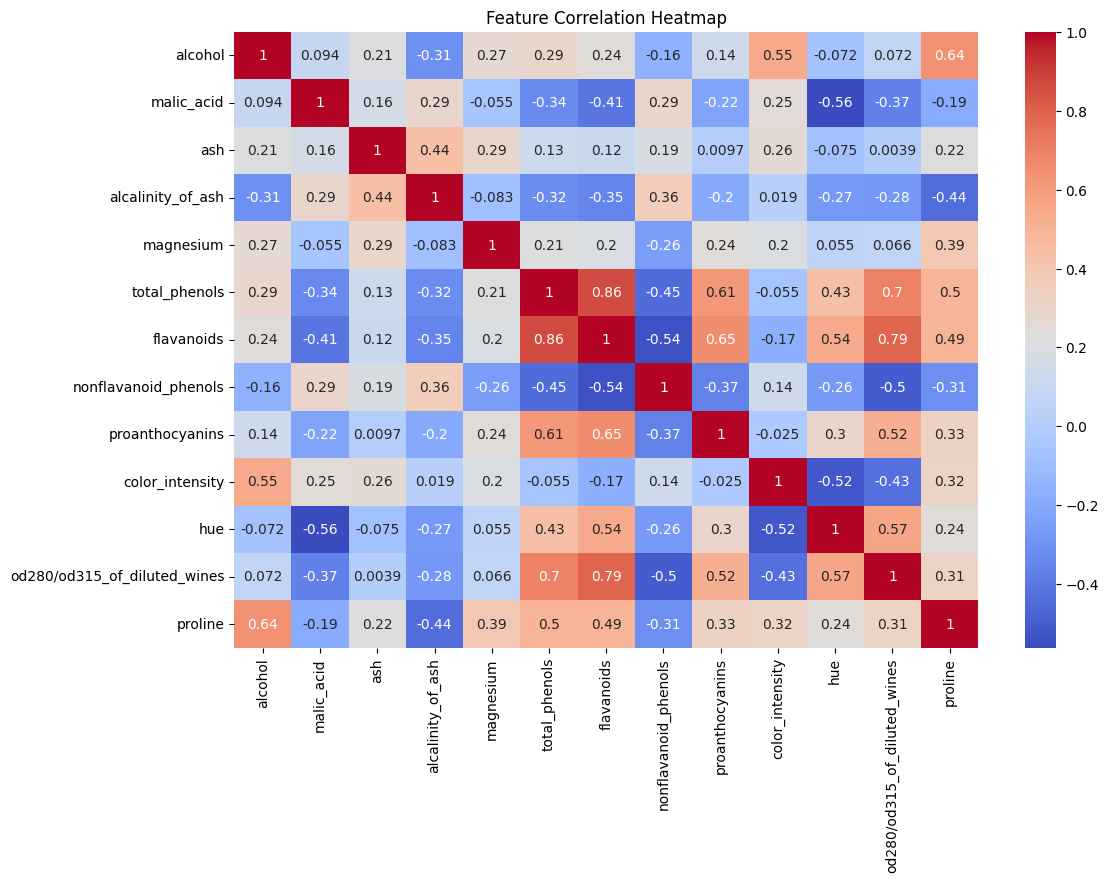

In [14]:
plt.figure(figsize=(12,8))   # Correlation heatmap
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()  

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)   #Train-Test Split
print("Test set size:", X_test.shape)

Training set size: (142, 13)
Test set size: (36, 13)


In [17]:
from sklearn.preprocessing import StandardScaler   #feature scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
from imblearn.over_sampling import SMOTE   # to deal with class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Resampled training target distribution:\n", pd.Series(y_train_res).value_counts())

Resampled training target distribution:
 target
0    57
2    57
1    57
Name: count, dtype: int64


In [19]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold # For Hyperparameter Tuning using gridsearch cv

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine'],
    'p': [1, 2, 3]
}

knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(knn, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Best CV accuracy: 0.9766386554621848


In [20]:
best_knn = grid_search.best_estimator_ #Training KNN model
best_knn.fit(X_train_res, y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


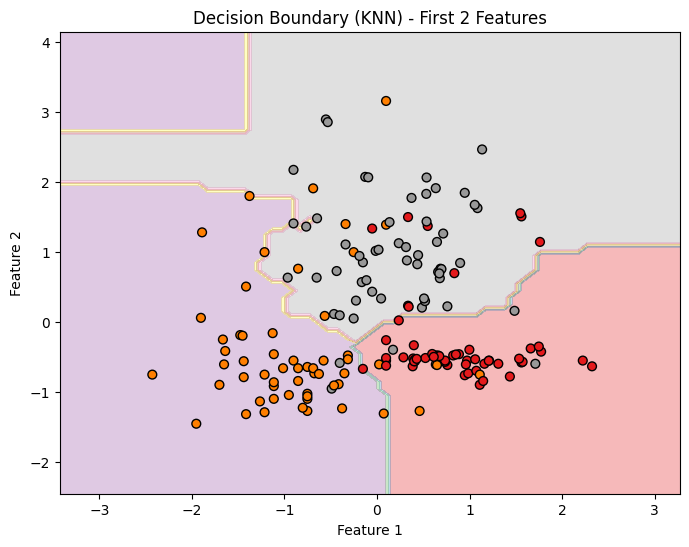

In [ ]:
# Part 8: Train best KNN model
best_knn = grid_search.best_estimator_
best_knn.fit(X_train_res, y_train_res)


import numpy as np
from sklearn.neighbors import KNeighborsClassifier

def plot_decision_boundary(model, X, y, feature_indices=[0, 1]):
    
    model_2d = KNeighborsClassifier(
        n_neighbors=model.n_neighbors,
        weights=model.weights,
        metric=model.metric
    )
    model_2d.fit(X, y)
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor='k', cmap='Set1')
    plt.xlabel(f'Feature {feature_indices[0]+1}')
    plt.ylabel(f'Feature {feature_indices[1]+1}')
    plt.title("Decision Boundary (KNN) - First 2 Features")
    plt.show()
plot_decision_boundary(best_knn, X_train_res[:, :2], y_train_res) #Using only first 2 scaled features for visualization

========== CONFUSION MATRIX ==========
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]



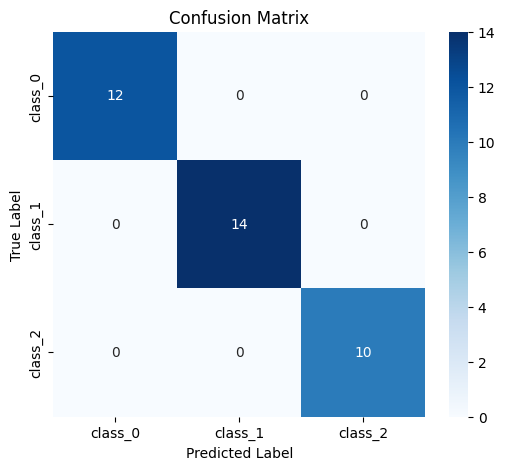

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


========== TEST ACCURACY ==========
Accuracy: 1.0000


In [31]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred = best_knn.predict(X_test_scaled)

print("========== CONFUSION MATRIX ==========")
print(confusion_matrix(y_test, y_pred))
print("======================================\n")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


print("========== CLASSIFICATION REPORT ==========")
print(classification_report(y_test, y_pred, target_names=wine.target_names))
print("===========================================\n")

accuracy = accuracy_score(y_test, y_pred)
print("========== TEST ACCURACY ==========")
print(f"Accuracy: {accuracy:.4f}")
print("==================================")